# Workshop 3: Data Exploration — Solution Notebook

**Severstal Steel Defect Detection Dataset**

This notebook walks through the data exploration homework questions with full solutions.

**Dataset:** Download from [Kaggle — Severstal Steel Defect Detection](https://www.kaggle.com/c/severstal-steel-defect-detection/data)  
You need: `train.csv` and the `train_images/` folder.

---

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from collections import Counter

# ============================================================
# CHANGE THIS to where you downloaded/extracted the dataset
# ============================================================
DATA_DIR = "R:/Datasets/severstal-steel-defect-detection"

TRAIN_IMAGES = os.path.join(DATA_DIR, "train_images")

# Verify the path works
assert os.path.exists(DATA_DIR), f"Data directory not found: {DATA_DIR}"
assert os.path.exists(TRAIN_IMAGES), f"Train images folder not found: {TRAIN_IMAGES}"
print("Paths look good!")

Paths look good!


In [2]:
# Load the CSV
df = pd.read_csv(os.path.join(DATA_DIR, "train.csv"))
print(f"CSV loaded: {df.shape[0]} rows, {df.shape[1]} columns")

CSV loaded: 7095 rows, 3 columns


---
## Part 1 — Getting Oriented (5 min)

### Q1. Load `train.csv` and examine its structure.
How many rows does it have? What are the columns? Why doesn't the row count match the number of images?

In [3]:
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print()
df.head(10)

Shape: (7095, 3)
Columns: ['ImageId', 'ClassId', 'EncodedPixels']



,ImageId,ClassId,EncodedPixels
0,0002cc93b.jpg,1,29102 12 29346 24 29602 24 29858 24 30114 24 3...
1,0007a71bf.jpg,3,18661 28 18863 82 19091 110 19347 110 19603 11...
2,000a4bcdd.jpg,1,37607 3 37858 8 38108 14 38359 20 38610 25 388...
3,000f6bf48.jpg,4,131973 1 132228 4 132483 6 132738 8 132993 11 ...
4,0014fce06.jpg,3,229501 11 229741 33 229981 55 230221 77 230468...
5,0025bde0c.jpg,3,8458 14 8707 35 8963 48 9219 71 9475 88 9731 8...
6,0025bde0c.jpg,4,315139 8 315395 15 315651 16 315906 17 316162 ...
7,002af848d.jpg,4,290800 6 291055 13 291311 15 291566 18 291822 ...
8,002fc4e19.jpg,1,146021 3 146275 10 146529 40 146783 46 147038 ...
9,002fc4e19.jpg,2,145658 7 145901 20 146144 33 146386 47 146629 ...


**Answer:** The CSV has 3 columns — `ImageId`, `ClassId`, and `EncodedPixels`.

The row count is larger than the image count because a single image can appear **multiple times** — once for each defect class it contains. An image with both Class 1 and Class 3 defects gets two rows.

The `EncodedPixels` column uses Run-Length Encoding (RLE) to store the exact pixel locations of each defect. For our classification task we only care about whether this field is filled in or not — if it has a value, that image has a defect of the corresponding `ClassId`.

### Q2. How many unique images are in the CSV vs. the folder?

In [4]:
unique_in_csv = df["ImageId"].nunique()
total_in_folder = len(os.listdir(TRAIN_IMAGES))

print(f"Unique images in CSV:      {unique_in_csv}")
print(f"Total images in folder:    {total_in_folder}")
print(f"Difference (no defect):    {total_in_folder - unique_in_csv}")

Unique images in CSV:      6666
Total images in folder:    12568
Difference (no defect):    5902


**Answer:** The folder has more images than the CSV has unique `ImageId` values. The "missing" ones are images with **no defects at all** — they simply aren't listed in the CSV because there's nothing to annotate.

### Q3. What are the unique defect class IDs? Are there rows with empty `EncodedPixels`?

In [5]:
print(f"Unique ClassIds: {sorted(df['ClassId'].unique())}")
print(f"Rows with null EncodedPixels: {df['EncodedPixels'].isnull().sum()}")
print(f"Rows with valid EncodedPixels: {df['EncodedPixels'].notna().sum()}")

Unique ClassIds: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Rows with null EncodedPixels: 0
Rows with valid EncodedPixels: 7095


**Answer:** There are 4 defect classes (1, 2, 3, 4). Some rows may have null `EncodedPixels`, meaning that class of defect is NOT present in that image. This is how the original competition CSV was structured — some versions of the data include these null rows, some don't.

---
## Part 2 — Class Distribution (5–7 min)

### Q4. Count defective images per class and make a bar chart.

In [6]:
# Keep only rows that actually have a defect
defective = df[df["EncodedPixels"].notna()].copy()
print(f"Total defect annotations: {len(defective)}")
print()

# Count per class
class_counts = defective["ClassId"].value_counts().sort_index()
print("Defect counts per class:")
print(class_counts)
print()
print(f"Most common / Least common ratio: {class_counts.max() / class_counts.min():.1f}x")

Total defect annotations: 7095

Defect counts per class:
ClassId
1     897
2     247
3    5150
4     801
Name: count, dtype: int64

Most common / Least common ratio: 20.9x


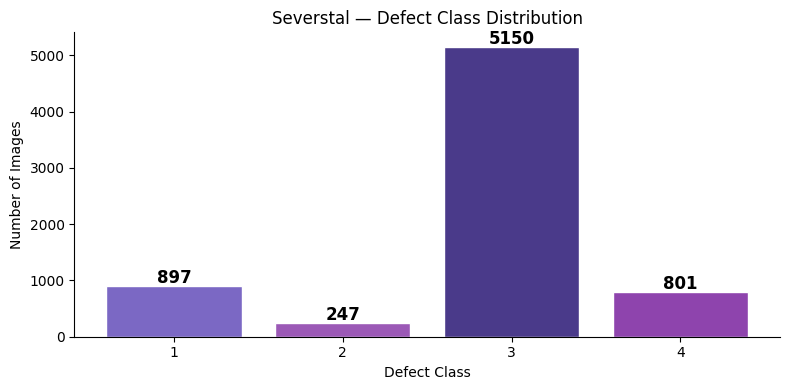

In [7]:
# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))

colors = ["#7B68C4", "#9B59B6", "#4A3A8A", "#8E44AD"]
bars = ax.bar(class_counts.index.astype(str), class_counts.values, color=colors, edgecolor="white")

# Add count labels on top of each bar
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            str(count), ha="center", fontweight="bold", fontsize=12)

ax.set_xlabel("Defect Class")
ax.set_ylabel("Number of Images")
ax.set_title("Severstal — Defect Class Distribution")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

**Answer:** Class 3 dominates the dataset massively (~5,150 images) while Class 2 is severely underrepresented (~247 images). That's roughly a **21:1 ratio** — a serious class imbalance. Without handling this, a model could get decent accuracy by simply predicting "Class 3" for everything while completely failing on rare defect types.

### Q5. How many images have no defect at all?

In [8]:
# All images in the folder
all_images = set(os.listdir(TRAIN_IMAGES))

# Images that have at least one defect
defective_images = set(defective["ImageId"].unique())

# No defect = in folder but not in the defective set
no_defect_images = all_images - defective_images

print(f"Total images in folder:   {len(all_images)}")
print(f"Defective images:         {len(defective_images)}")
print(f"No-defect images:         {len(no_defect_images)}")
print(f"Defective percentage:     {len(defective_images) / len(all_images) * 100:.1f}%")
print(f"No-defect percentage:     {len(no_defect_images) / len(all_images) * 100:.1f}%")

Total images in folder:   12568
Defective images:         6666
No-defect images:         5902
Defective percentage:     53.0%
No-defect percentage:     47.0%


**Answer:** Roughly half the dataset is defect-free and half has at least one defect. This is actually a fairly balanced split for the binary question (defect vs. no defect), but the 4-class defect breakdown within the defective images is highly skewed.

### Q6. Full 5-class sample count table

In [9]:
# Build the full 5-class summary
summary = {f"Class {i}": class_counts.get(i, 0) for i in [1, 2, 3, 4]}
summary["No Defect"] = len(no_defect_images)

summary_df = pd.DataFrame({
    "Class": summary.keys(),
    "Count": summary.values()
})
summary_df["Percentage"] = (summary_df["Count"] / summary_df["Count"].sum() * 100).round(1)
print(summary_df.to_string(index=False))

    Class  Count  Percentage
  Class 1    897         6.9
  Class 2    247         1.9
  Class 3   5150        39.6
  Class 4    801         6.2
No Defect   5902        45.4


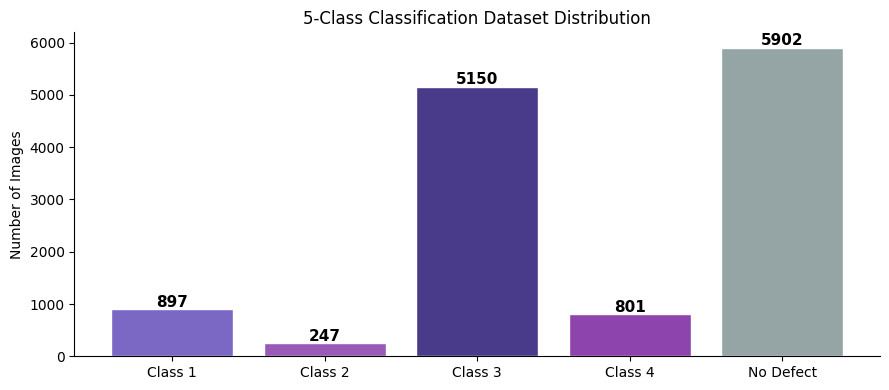

In [10]:
# Visualize all 5 classes together
fig, ax = plt.subplots(figsize=(9, 4))

labels = list(summary.keys())
values = list(summary.values())
colors = ["#7B68C4", "#9B59B6", "#4A3A8A", "#8E44AD", "#95A5A6"]

bars = ax.bar(labels, values, color=colors, edgecolor="white")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            str(val), ha="center", fontweight="bold", fontsize=11)

ax.set_ylabel("Number of Images")
ax.set_title("5-Class Classification Dataset Distribution")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

**Answer:** This is clearly imbalanced. "No Defect" and "Class 3" dominate while "Class 2" has very few samples. A naive model would likely overfit to the majority classes and perform poorly on Class 2 and Class 4. We'd need strategies like weighted loss functions, oversampling of minority classes, or targeted data augmentation.

---
## Part 3 — Multi-Label Investigation (5–7 min)

### Q7. Can a single image have more than one defect type?

In [11]:
# For each defective image, count how many distinct defect classes it has
defects_per_image = defective.groupby("ImageId")["ClassId"].nunique()

print("Number of defect classes per image:")
print(defects_per_image.value_counts().sort_index())
print()
print(f"Images with exactly 1 defect type: {(defects_per_image == 1).sum()}")
print(f"Images with 2+ defect types:       {(defects_per_image > 1).sum()}")
print(f"Multi-defect percentage:            {(defects_per_image > 1).mean() * 100:.1f}%")

Number of defect classes per image:
ClassId
1    6239
2     425
3       2
Name: count, dtype: int64

Images with exactly 1 defect type: 6239
Images with 2+ defect types:       427
Multi-defect percentage:            6.4%


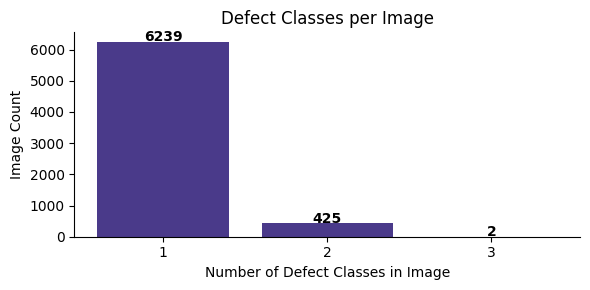

In [12]:
# Quick bar chart
fig, ax = plt.subplots(figsize=(6, 3))
counts = defects_per_image.value_counts().sort_index()
ax.bar(counts.index.astype(str), counts.values, color="#4A3A8A")
for i, (x, y) in enumerate(zip(counts.index, counts.values)):
    ax.text(i, y + 20, str(y), ha="center", fontweight="bold")
ax.set_xlabel("Number of Defect Classes in Image")
ax.set_ylabel("Image Count")
ax.set_title("Defect Classes per Image")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

**Answer:** Yes! Some images have more than one defect type. The vast majority have exactly one, but there are images with two (or even three) defect classes simultaneously. This makes the problem technically a **multi-label** classification problem, not a simple single-label one.

### Q8. Which class combinations appear in multi-defect images?

In [13]:
# Get the class combination for each image as a tuple
class_combos = defective.groupby("ImageId")["ClassId"].apply(
    lambda x: tuple(sorted(x.unique()))
)

# Filter to multi-defect only
multi_defect = class_combos[class_combos.apply(len) > 1]

print(f"Total multi-defect images: {len(multi_defect)}")
print()
print("Most common multi-defect combinations:")
print(multi_defect.value_counts().head(10))

Total multi-defect images: 427

Most common multi-defect combinations:
ClassId
(3, 4)       284
(1, 3)        91
(1, 2)        35
(2, 3)        14
(1, 2, 3)      2
(2, 4)         1
Name: count, dtype: int64


**Answer:** The most frequent combination tends to be Classes 1 & 3 or 3 & 4. This makes physical sense — certain manufacturing issues can produce multiple defect types simultaneously. Knowing which classes co-occur helps us decide how to handle them.

### Q9. How would you handle multi-label images for a single-label classifier?

*(Written answer — no code)*

**Some strategies:**

1. **Exclude them** — Since multi-defect images are a small percentage, just drop them from the dataset. Simple, but you lose data.

2. **Pick the rarest class** — If an image has Class 2 and Class 3, label it as Class 2 since that's the class we have the fewest samples for. This helps with class imbalance too.

3. **Duplicate into multiple classes** — Copy the image into both class folders. The model sees it as two separate training examples. Downside: the same image appears in two classes, which could confuse the model.

4. **Create a "multi-defect" class** — Treat images with 2+ defect types as a separate 5th defect class. Only works if there are enough of them.

5. **Frame it as multi-label** — Use sigmoid outputs instead of softmax, and binary cross-entropy loss per class. This is the most correct approach but adds complexity.

For this course, strategy 1 or 2 are the most practical starting points.

---
## Part 4 — Visual Inspection (5–7 min)

### Q10. Display sample images from each defect class

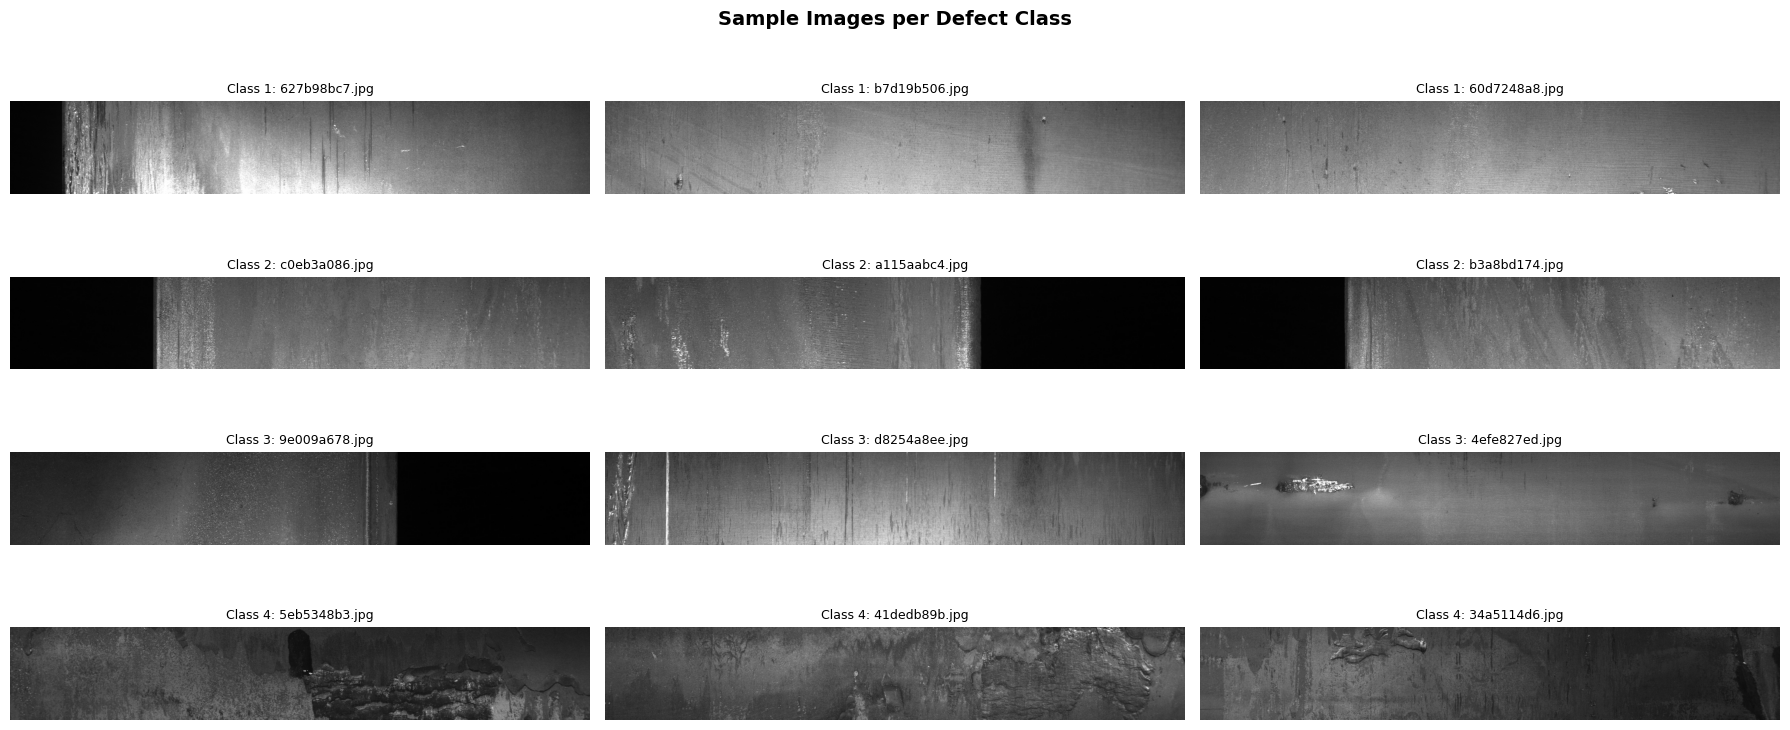

In [14]:
np.random.seed(42)  # For reproducibility

fig, axes = plt.subplots(4, 3, figsize=(18, 8))

for row, class_id in enumerate([1, 2, 3, 4]):
    # Get image names for this class
    class_images = defective[defective["ClassId"] == class_id]["ImageId"].unique()
    samples = np.random.choice(class_images, size=3, replace=False)

    for col, img_name in enumerate(samples):
        img_path = os.path.join(TRAIN_IMAGES, img_name)
        img = Image.open(img_path)
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(f"Class {class_id}: {img_name}", fontsize=9)
        axes[row, col].axis("off")

plt.suptitle("Sample Images per Defect Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Things to notice:**
- Some defects are extremely subtle — barely visible to the human eye
- Class 1 and Class 4 can look similar (both have fine-scale features)
- Class 3 defects tend to be more obvious (larger, denser patterns)
- Class 2 shows diffuse patches that are hard to pin down
- The images are very wide and narrow (1600×256) — like looking at a strip of steel on a conveyor

### Q11. Do the "no defect" images really look clean?

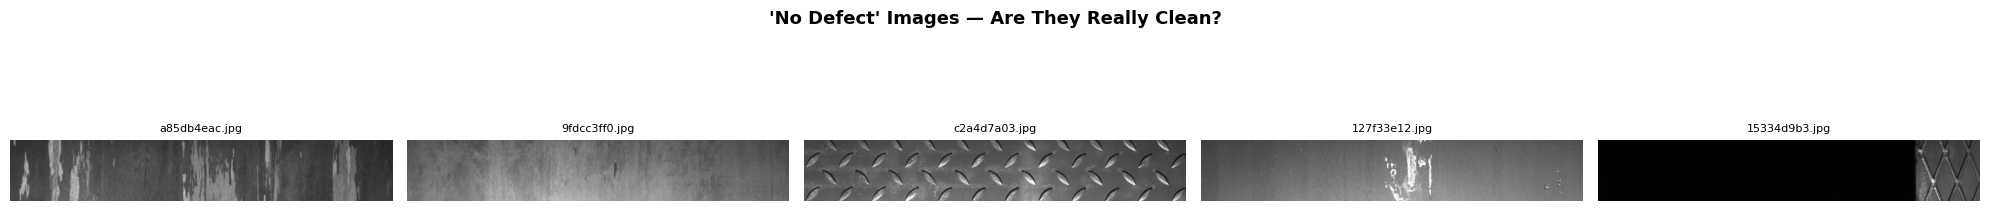

In [15]:
np.random.seed(123)
no_defect_samples = np.random.choice(list(no_defect_images), size=5, replace=False)

fig, axes = plt.subplots(1, 5, figsize=(20, 3))
for i, img_name in enumerate(no_defect_samples):
    img_path = os.path.join(TRAIN_IMAGES, img_name)
    img = Image.open(img_path)
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(f"{img_name}", fontsize=8)
    axes[i].axis("off")

plt.suptitle("'No Defect' Images — Are They Really Clean?", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

**Answer:** Some "no defect" images actually show visible marks, scratches, or texture variations. This doesn't necessarily mean they're mislabeled — the annotation only covers the 4 specific defect types defined by Severstal. Other surface marks that don't fall into those 4 categories are still considered "no defect" for this dataset.

This is a **real-world data quality challenge**: the label space doesn't capture everything you can see. Your model might pick up on these patterns and get confused.

### Q12. Image dimensions — what are we working with?

In [16]:
# Check a sample image
sample_name = os.listdir(TRAIN_IMAGES)[0]
sample_img = Image.open(os.path.join(TRAIN_IMAGES, sample_name))

print(f"Image: {sample_name}")
print(f"Size (W x H): {sample_img.size}")
print(f"Aspect ratio: {sample_img.size[0] / sample_img.size[1]:.1f}:1")
print(f"Mode: {sample_img.mode}")

Image: 0002cc93b.jpg
Size (W x H): (1600, 256)
Aspect ratio: 6.2:1
Mode: RGB


In [17]:
# Let's verify ALL images are the same size
# (Check a random sample of 100 to save time)
sample_files = np.random.choice(os.listdir(TRAIN_IMAGES), size=100, replace=False)
sizes = set()
for fname in sample_files:
    img = Image.open(os.path.join(TRAIN_IMAGES, fname))
    sizes.add(img.size)

print(f"Unique image sizes found: {sizes}")
if len(sizes) == 1:
    print("All images are the same size.")

Unique image sizes found: {(1600, 256)}
All images are the same size.


**Answer:** All images are 1600×256 pixels — that's a 6.25:1 aspect ratio. This is very far from the square 224×224 that most pretrained models expect.

Options to deal with this:
- **Resize to square** — Fast, but squishes the image and distorts defect shapes
- **Crop tiles** — Cut each image into, say, 4 tiles of 400×256 (or resize tiles to 256×256). Preserves aspect ratio better, and you get 4× the training samples, but you might cut a defect in half
- **Pad to square** — Add gray borders to make it 1600×1600, then resize. Preserves everything but wastes a lot of the input on padding

---
## Part 5 — Thinking Ahead (3–5 min)

### Q13. Top 3 data challenges before training a classifier

Based on everything we've found:

1. **Severe class imbalance** — Class 3 has ~21× more samples than Class 2. A model trained naively will be biased toward the majority class and will have poor recall on rare defect types. We'll need weighted losses, oversampling, or augmentation to fix this.

2. **Extreme aspect ratio** — Images are 1600×256, but standard models expect square inputs. We need a resizing strategy that doesn't destroy the defect signal. Tiling is probably the best option here.

3. **Multi-label ambiguity** — Some images contain multiple defect types, but a simple classifier can only assign one label. We need a strategy for these images, and we need to be aware that our "accuracy" metric might be misleading if we ignore this.

**Bonus challenges:**
- Noisy "no defect" labels (visible marks in clean images)
- Very subtle defects in some classes (hard even for humans)
- Class 1 and Class 4 are visually similar (likely to confuse the model)

### Q14. What information are we throwing away by reducing this to classification?

The `EncodedPixels` column contains **exact pixel-level defect masks** — we know precisely which pixels are defective and which aren't. By reducing this to an image-level label, we're throwing away:

- **Defect location** — Where on the steel strip is the defect? Is it on the edge or the center?
- **Defect size** — How many pixels are affected? Is it a tiny speck or a large region?
- **Defect shape** — Is it a line, a blob, scattered points?

This information matters when:
- Defect **severity** depends on size (a 5-pixel scratch vs. a 500-pixel crack)
- Defect **location** affects downstream quality (edge defects might get trimmed away)
- You need to provide actionable feedback to the production line ("where" matters, not just "what")

For our workshop, classification is a good starting point, but in a real production system, you'd likely want segmentation for full defect localization.

---
## Bonus: Understanding the RLE Format

Since we've been using `EncodedPixels` only to check "is there a defect?" — let's actually decode one mask to see what the data really contains.

In [18]:
def rle_to_mask(rle_string, height=256, width=1600):
    """
    Convert a Run-Length Encoded string to a binary mask.

    RLE format: pairs of (start_pixel, run_length)
    Pixels are numbered column-first (top to bottom, then left to right).
    """
    mask = np.zeros(height * width, dtype=np.uint8)

    # Split the string into numbers
    pairs = list(map(int, rle_string.split()))

    # Each pair: (start, length)
    for i in range(0, len(pairs), 2):
        start = pairs[i] - 1       # RLE is 1-indexed, Python is 0-indexed
        length = pairs[i + 1]
        mask[start:start + length] = 1

    # Reshape: column-first ordering (Fortran order)
    mask = mask.reshape((height, width), order="F")
    return mask

In [19]:
# Pick a sample defective image and decode its mask
sample_row = defective.iloc[0]
img_name = sample_row["ImageId"]
class_id = sample_row["ClassId"]
rle = sample_row["EncodedPixels"]

print(f"Image: {img_name}")
print(f"Class: {class_id}")
print(f"RLE (first 100 chars): {rle[:100]}...")

# Decode
mask = rle_to_mask(rle)
print(f"Mask shape: {mask.shape}")
print(f"Defective pixels: {mask.sum()} out of {mask.size} ({mask.mean() * 100:.2f}%)")

Image: 0002cc93b.jpg
Class: 1
RLE (first 100 chars): 29102 12 29346 24 29602 24 29858 24 30114 24 30370 24 30626 24 30882 24 31139 23 31395 23 31651 23 3...
Mask shape: (256, 1600)
Defective pixels: 4396 out of 409600 (1.07%)


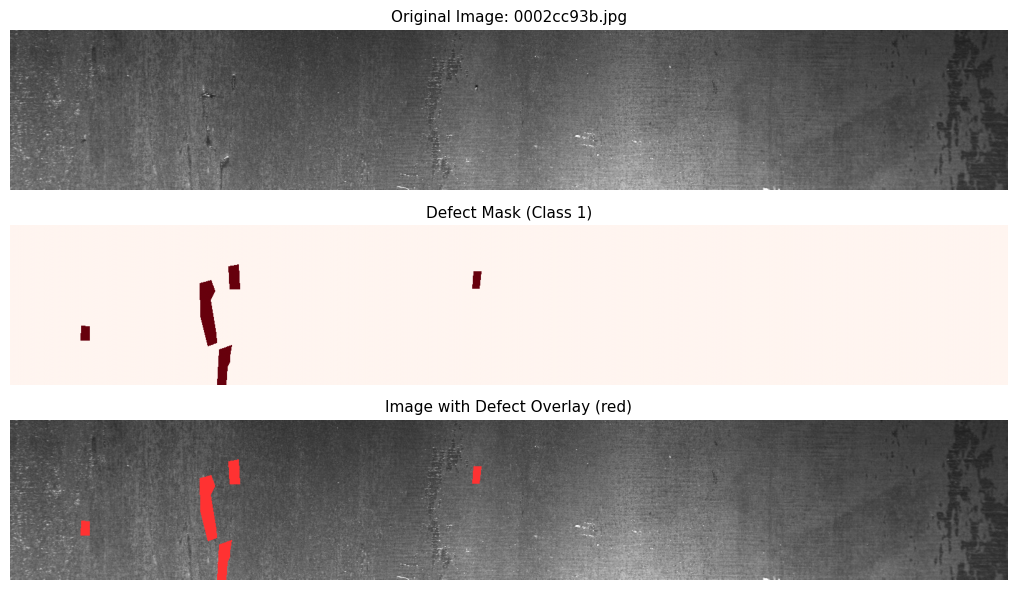

In [20]:
# Show the image with the defect mask overlaid
img = np.array(Image.open(os.path.join(TRAIN_IMAGES, img_name)))

fig, axes = plt.subplots(3, 1, figsize=(16, 6))

# Original image
axes[0].imshow(img, cmap="gray")
axes[0].set_title(f"Original Image: {img_name}", fontsize=11)
axes[0].axis("off")

# Mask only
axes[1].imshow(mask, cmap="Reds")
axes[1].set_title(f"Defect Mask (Class {class_id})", fontsize=11)
axes[1].axis("off")

# Overlay
overlay = img.copy()
if len(overlay.shape) == 2:
    overlay = np.stack([overlay] * 3, axis=-1)  # Convert to RGB
overlay[mask == 1] = [255, 50, 50]  # Red where defect is

axes[2].imshow(overlay)
axes[2].set_title("Image with Defect Overlay (red)", fontsize=11)
axes[2].axis("off")

plt.tight_layout()
plt.show()

**This is what we're throwing away when we reduce to classification.** The mask tells us the exact shape, size, and location of the defect. For classification, we just collapse all of that into a single label: "this image has Class X."

---
## Summary of Key Findings

| Finding | Value |
|---------|-------|
| Total images | ~12,568 |
| Defective images | ~6,666 |
| No-defect images | ~5,902 |
| Defect classes | 4 (numbered 1–4) |
| Most common class | Class 3 (~5,150) |
| Rarest class | Class 2 (~247) |
| Imbalance ratio | ~21:1 |
| Multi-defect images | Small % |
| Image dimensions | 1600×256 (6.25:1 aspect ratio) |
| Annotation type | Pixel-level RLE masks |

### Challenges for Classification
1. Severe class imbalance
2. Extreme aspect ratio (not square)
3. Multi-label images exist
4. Noisy "no defect" labels
5. Visually similar defect classes (1 vs 4)